 # CS480: Introduction to Quantum Computing

 ## Homework 3: Gate Operations

 **Due:** Sunday 11:59 PM

 **Total Points:** 80



 ### Instructions

 - Complete all exercises in this notebook

 - Run all cells to verify your answers

 - Submit the completed .ipynb file to Canvas



 ### This homework covers:

 - Part 1: Creating Superposition States (20 pts)

 - Part 2: Interference Experiments (20 pts)

 - Part 3: Gate Identities (20 pts)

 - Part 4: Gate Decomposition (10 pts)

 - Part 5: Challenge (10 pts)

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt


 ---

 ## Part 1: Creating Superposition States (20 points)

 ### Exercise 1.1 (5 points)

 Create a state with **60% probability of |0⟩** and **40% probability of |1⟩**:

 $$|\psi\rangle = \sqrt{0.6}|0\rangle + \sqrt{0.4}|1\rangle$$



 Calculate the required angle θ for `Ry(θ)` and implement it.

In [3]:
theta_1_1 = 2 * np.arccos(np.sqrt(0.6))  # TODO: Calculate and set the correct angle (use np.arccos)

qc_1_1 = QuantumCircuit(1)
# TODO: Apply the appropriate rotation
qc_1_1.ry(theta_1_1, 0)

state_1_1 = Statevector(qc_1_1)
probs = [abs(a)**2 for a in state_1_1.data]
print("Exercise 1.1:")
print(f"  State: {np.round(state_1_1.data, 4)}")
print(f"  P(0) = {probs[0]:.4f} (expected: 0.60)")
print(f"  P(1) = {probs[1]:.4f} (expected: 0.40)")


Exercise 1.1:
  State: [0.7746+0.j 0.6325+0.j]
  P(0) = 0.6000 (expected: 0.60)
  P(1) = 0.4000 (expected: 0.40)


 ### Exercise 1.2 (5 points)

 Create the state with a relative phase of $\pi/3$:

 $$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{i\pi/3}|1\rangle)$$


Exercise 1.2:
  State: [0.6124-0.3536j 0.6124+0.3536j]
  Expected: [0.7071+0j, 0.3536+0.6124j]


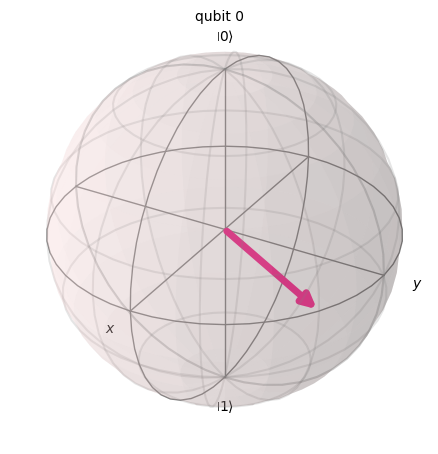

In [4]:
qc_1_2 = QuantumCircuit(1)
# TODO: Create the state using H and Rz (or other gates)
qc_1_2.h(0)
qc_1_2.rz(np.pi/3, 0)

state_1_2 = Statevector(qc_1_2)
print("\nExercise 1.2:")
print(f"  State: {np.round(state_1_2.data, 4)}")
print(f"  Expected: [0.7071+0j, 0.3536+0.6124j]")
display(plot_bloch_multivector(state_1_2))


 ### Exercise 1.3 (5 points)

 Create the state $|-i\rangle = \frac{1}{\sqrt{2}}(|0\rangle - i|1\rangle)$



 This state is on the **-Y axis** of the Bloch sphere.

In [5]:
qc_1_3 = QuantumCircuit(1)
# TODO: Create the |-i⟩ state
qc_1_3.h(0)
qc_1_3.z(0) 
qc_1_3.s(0)

state_1_3 = Statevector(qc_1_3)
print("\nExercise 1.3:")
print(f"  State: {np.round(state_1_3.data, 4)}")
print(f"  Expected: [0.7071+0j, 0-0.7071j]")



Exercise 1.3:
  State: [0.7071+0.j     0.    -0.7071j]
  Expected: [0.7071+0j, 0-0.7071j]


 ### Exercise 1.4 (5 points)

 Create a state at $\theta=2\pi/3$, $\phi=\pi/4$ on the Bloch sphere:

 $$|\psi\rangle = \cos(\pi/3)|0\rangle + e^{i\pi/4}\sin(\pi/3)|1\rangle$$


Exercise 1.4:
  State: [0.4619-0.1913j 0.8001+0.3314j]


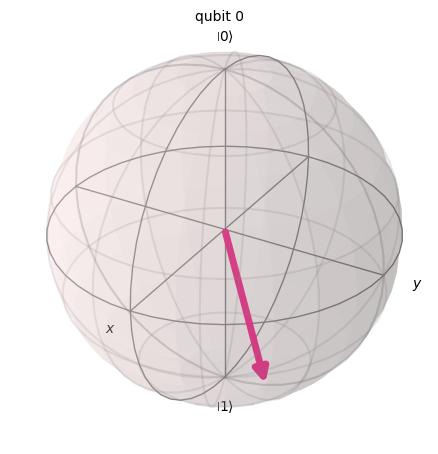

In [6]:
qc_1_4 = QuantumCircuit(1)
# TODO: Create this state using Ry and Rz
qc_1_4.ry(2*np.pi/3, 0)
qc_1_4.rz(np.pi/4, 0)

state_1_4 = Statevector(qc_1_4)
print("\nExercise 1.4:")
print(f"  State: {np.round(state_1_4.data, 4)}")
# Verify with Bloch sphere
display(plot_bloch_multivector(state_1_4))


 ---

 ## Part 2: Interference Experiments (20 points)

 ### Exercise 2.1 (6 points)

 Create a plot showing the interference pattern for **H - Rz(φ) - H** applied to |0⟩.



 - Plot P(0) vs φ for φ ∈ [0, 2π]

 - Use at least 30 data points

 - Label axes and add a title

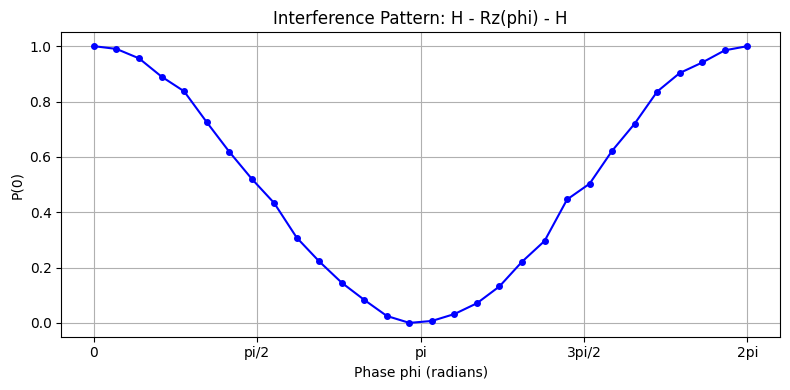

In [7]:
phases = np.linspace(0, 2*np.pi, 30)
prob_zero = []

for phi in phases:
    qc = QuantumCircuit(1, 1)
    # TODO: Build H - Rz(φ) - H circuit and measure
    qc.h(0)
    qc.rz(phi, 0)
    qc.h(0)
    qc.measure(0, 0)

    sim = AerSimulator()
    result = sim.run(qc, shots=1000).result()
    counts = result.get_counts()
    p0 = counts.get('0', 0) / 1000
    prob_zero.append(p0)

plt.figure(figsize=(8, 4))
plt.plot(phases, prob_zero, 'b-o', markersize=4)
plt.xlabel('Phase phi (radians)')
plt.ylabel('P(0)')
plt.title('Interference Pattern: H - Rz(phi) - H')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', 'pi/2', 'pi', '3pi/2', '2pi'])
plt.grid(True)
plt.tight_layout()
plt.show()





 ### Exercise 2.2 (7 points)

 Compare interference patterns: **H-Rz(φ)-H** vs **H-Rx(φ)-H**



 - Plot both on the same graph with different colors

 - Add a legend

 - In a comment, explain why the patterns are different

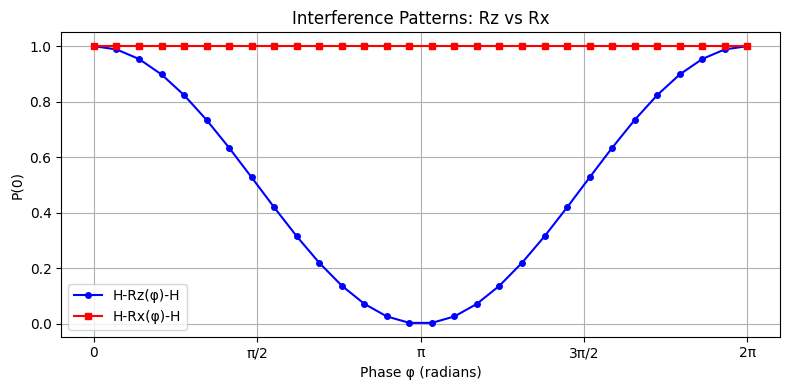

In [8]:
phases = np.linspace(0, 2*np.pi, 30)
prob_rz = []
prob_rx = []

for phi in phases:
    # H - Rz(phi) - H
    qc_rz = QuantumCircuit(1)
    qc_rz.h(0)
    qc_rz.rz(phi, 0)
    qc_rz.h(0)
    state_rz = Statevector(qc_rz)
    prob_rz.append(abs(state_rz.data[0])**2)

    # H - Rx(phi) - H
    qc_rx = QuantumCircuit(1)
    qc_rx.h(0)
    qc_rx.rx(phi, 0)
    qc_rx.h(0)
    state_rx = Statevector(qc_rx)
    prob_rx.append(abs(state_rx.data[0])**2)

plt.figure(figsize=(8, 4))
plt.plot(phases, prob_rz, 'b-o', markersize=4, label='H-Rz(φ)-H')
plt.plot(phases, prob_rx, 'r-s', markersize=4, label='H-Rx(φ)-H')
plt.xlabel('Phase φ (radians)')
plt.ylabel('P(0)')
plt.title('Interference Patterns: Rz vs Rx')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# YOUR EXPLANATION (why are the patterns different?):

# Rz rotates around the Z-axis, so H-Rz-H creates a cosine wave pattern.
# Rx rotates around the X-axis, but |+> already sits on the X-axis,
# so Rx has no effect on it and P(0) stays flat at 1.

 ### Exercise 2.3 (7 points)

 Implement a function that computes the **exact** P(0) for H-Rz(φ)-H using Statevector (no sampling).



 Then plot the exact result vs the simulated result (from 2.1) on the same graph.

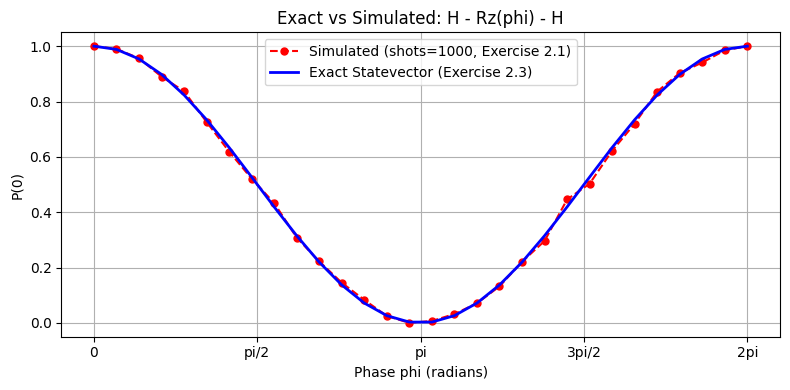

In [9]:
def exact_prob_zero(phi):
    """Compute exact P(0) for H-Rz(φ)-H using Statevector."""
    qc = QuantumCircuit(1)
    # TODO: Build circuit (no measurement needed)
    # TODO: Get statevector and return |amplitude_0|^2
    qc.h(0)
    qc.rz(phi, 0)
    qc.h(0)
    state = Statevector(qc)
    return abs(state.data[0])**2

phases = np.linspace(0, 2*np.pi, 30)
exact_probs = [exact_prob_zero(phi) for phi in phases]

plt.figure(figsize=(8, 4))
plt.plot(phases, prob_zero, 'r--o', markersize=5, label='Simulated (shots=1000, Exercise 2.1)')
plt.plot(phases, exact_probs, 'b-', linewidth=2, label='Exact Statevector (Exercise 2.3)')
plt.xlabel('Phase phi (radians)')
plt.ylabel('P(0)')
plt.title('Exact vs Simulated: H - Rz(phi) - H')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', 'pi/2', 'pi', '3pi/2', '2pi'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

 ---

 ## Part 3: Gate Identities (20 points)

 ### Exercise 3.1 (5 points)

 Verify numerically that $XZ = -ZX$ (anti-commutation).



 Show both matrices and their sum.

In [10]:
# TODO: Create circuits for XZ and ZX
# Remember: for matrix AB, apply B first, then A in Qiskit

qc_xz = QuantumCircuit(1)
# TODO
qc_xz.z(0)  # Z applied first
qc_xz.x(0)  # X applied second

qc_zx = QuantumCircuit(1)
# TODO
qc_zx.x(0)  # X applied first
qc_zx.z(0)  # Z applied second



mat_xz = Operator(qc_xz).data
mat_zx = Operator(qc_zx).data

print("Exercise 3.1 - Anti-commutation XZ = -ZX:")
print("  XZ = ")
print(np.round(mat_xz, 4))
print("  ZX = ")
print(np.round(mat_zx, 4))
print("  XZ + ZX = ")
print(np.round(mat_xz + mat_zx, 4))


Exercise 3.1 - Anti-commutation XZ = -ZX:
  XZ = 
[[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]
  ZX = 
[[ 0.+0.j  1.+0.j]
 [-1.+0.j  0.+0.j]]
  XZ + ZX = 
[[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


 ### Exercise 3.2 (5 points)

 Verify the phase gate powers: $T^4 = Z$ and $T^8 = I$

In [11]:
# T^4
qc_t4 = QuantumCircuit(1)
# TODO: Apply T four times
qc_t4.t(0)
qc_t4.t(0)
qc_t4.t(0)
qc_t4.t(0)
    
# T^8
qc_t8 = QuantumCircuit(1)
# TODO: Apply T eight times
qc_t8.t(0)
qc_t8.t(0)
qc_t8.t(0)
qc_t8.t(0)
qc_t8.t(0)
qc_t8.t(0)
qc_t8.t(0)
qc_t8.t(0)
    
qc_z = QuantumCircuit(1)
qc_z.z(0)

qc_i = QuantumCircuit(1)
qc_i.id(0)

print("\nExercise 3.2 - Phase gate powers:")
print(f"  T⁴ = Z? {np.allclose(Operator(qc_t4).data, Operator(qc_z).data)}")
print(f"  T⁸ = I? {np.allclose(Operator(qc_t8).data, Operator(qc_i).data)}")



Exercise 3.2 - Phase gate powers:
  T⁴ = Z? True
  T⁸ = I? True


 ### Exercise 3.3 (5 points)

 Discover what gate $TXT^\dagger$ equals.



 **Note:** For matrix $TXT^\dagger$, write gates in reverse order: `tdg`, `x`, `t`

In [12]:
qc_txt = QuantumCircuit(1)
# TODO: Implement TXT† (remember reverse order!)
qc_txt.tdg(0)  # T† first
qc_txt.x(0)   # X second
qc_txt.t(0)   # T third
print("\nExercise 3.3 - Discover TXT†:")
print("  TXT† = ")
print(np.round(Operator(qc_txt).data, 4))

# Compare with X to see the difference
qc_x = QuantumCircuit(1)
qc_x.x(0)
print("  X = ")
print(np.round(Operator(qc_x).data, 4))

# What is the relationship? 
# YOUR ANSWER:
# It is NOT equal to X, Y, or Z directly, but it is a phase-rotated version of X.



Exercise 3.3 - Discover TXT†:
  TXT† = 
[[0.    +0.j     0.7071-0.7071j]
 [0.7071+0.7071j 0.    +0.j    ]]
  X = 
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


 ### Exercise 3.4 (5 points)

 Verify that $SXS^\dagger = Y$ by implementing the circuit and comparing matrices.



 **Remember:** For matrix $SXS^\dagger$, write gates in reverse order.

In [13]:
qc_sxs = QuantumCircuit(1)
# TODO: Implement SXS†
qc_sxs.s(0)
qc_sxs.s(0)
qc_sxs.s(0)  # S†
qc_sxs.x(0)
qc_sxs.s(0)  # S
qc_y = QuantumCircuit(1)
qc_y.y(0)

print("\nExercise 3.4 - Verify SXS† = Y:")
print("  SXS† = ")
print(np.round(Operator(qc_sxs).data, 4))
print("  Y = ")
print(np.round(Operator(qc_y).data, 4))
print(f"  Equal? {np.allclose(Operator(qc_sxs).data, Operator(qc_y).data)}")



Exercise 3.4 - Verify SXS† = Y:
  SXS† = 
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
  Y = 
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
  Equal? True


 ---

 ## Part 4: Gate Decomposition (10 points)

 ### Exercise 4.1 (5 points)

 Verify that $Z = HXH$ by showing the matrices are equal.

In [14]:
qc_hxh = QuantumCircuit(1)
# TODO: Implement HXH
qc_hxh.h(0)  # H first
qc_hxh.x(0)  # X second
qc_hxh.h(0)  # H third
qc_z = QuantumCircuit(1)
qc_z.z(0)

print("Exercise 4.1 - Z = HXH:")
print("  HXH = ")
print(np.round(Operator(qc_hxh).data, 4))
print("  Z = ")
print(np.round(Operator(qc_z).data, 4))
print(f"  Equal? {np.allclose(Operator(qc_hxh).data, Operator(qc_z).data)}")


Exercise 4.1 - Z = HXH:
  HXH = 
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
  Z = 
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
  Equal? True


 Exercise 4.2 (5 points)

 ZYZ Decomposition



 Decompose the Rx(π/3) gate using Rz and Ry:

 Rx(π/3) = e^(iα) Rz(β) Ry(γ) Rz(δ)



 Find α, β, γ, δ (hint: α can be ignored as global phase)

 The target matrix:

 Hint: Think about how to convert a rotation around the X-axis

 into rotations around Z and Y axes.

 YOUR SOLUTION:

 TODO: Implement Rz(β) Ry(γ) Rz(δ)

 qc_zyz.rz(beta, 0)

 qc_zyz.ry(gamma, 0)

 qc_zyz.rz(delta, 0)

 print("  Your ZYZ decomposition = ")

 print(np.round(Operator(qc_zyz).data, 4))

 Note: May differ from target by global phase

In [15]:
delta =  np.pi/2
gamma =  np.pi/3
beta  = -np.pi/2

# Target: Rx(pi/3)
qc_rx = QuantumCircuit(1)
qc_rx.rx(np.pi/3, 0)

# ZYZ decomposition: apply delta first, then gamma, then beta
qc_zyz = QuantumCircuit(1)
qc_zyz.rz(delta, 0)
qc_zyz.ry(gamma, 0)
qc_zyz.rz(beta, 0)

print('Exercise 4.2 - ZYZ decomposition of Rx(pi/3):')
print(f'  beta={beta:.4f}, gamma={gamma:.4f}, delta={delta:.4f}')
print('  Target Rx(pi/3) = ')
print(np.round(Operator(qc_rx).data, 4))
print('  Your ZYZ decomposition = ')
print(np.round(Operator(qc_zyz).data, 4))
print(f'  Equal? {np.allclose(Operator(qc_rx).data, Operator(qc_zyz).data)}')

Exercise 4.2 - ZYZ decomposition of Rx(pi/3):
  beta=-1.5708, gamma=1.0472, delta=1.5708
  Target Rx(pi/3) = 
[[0.866+0.j  0.   -0.5j]
 [0.   -0.5j 0.866+0.j ]]
  Your ZYZ decomposition = 
[[0.866+0.j  0.   -0.5j]
 [0.   -0.5j 0.866+0.j ]]
  Equal? True


 ---

 =============================================================================

 PART 5: CHALLENGE PROBLEM (10 points)

 =============================================================================

 Challenge 5.1 (10 points)

 Bloch Sphere Trajectory Visualization



 Visualize the path a qubit takes on the Bloch sphere when applying

 the gate sequence: Ry(π/4) → Rz(π/3) → Rx(π/2)



 Requirements:

   (a) Compute the Bloch (x, y, z) coordinates at each stage — 4 points

       total: |0⟩, after Ry, after Rz, after Rx  (3 pts)

   (b) Plot ALL four points on a single Bloch sphere with lines or

       arrows connecting consecutive points. Label each point

       (e.g., "Start |0⟩", "After Ry(π/4)", etc.)  (4 pts)

   (c) In a markdown cell below, describe the trajectory in 2-3

       sentences: which axis does each gate rotate around, and

       how does the path look on the sphere?  (3 pts)



 Hint: You can overlay multiple points on a Bloch sphere using

 qiskit.visualization.plot_bloch_vector with matplotlib, or build

 a 3D plot manually with matplotlib's Axes3D.

Extract Bloch sphere coordinates from a state vector.

 TODO: Build the circuit step by step and record coordinates

 Step 0: |0⟩

 Step 1: after Ry(π/4)

 Step 2: after Rz(π/3)

 Step 3: after Rx(π/2)

 TODO: Plot all four points on a Bloch sphere with connecting lines/arrows

 TODO: Label each point

 Your code and plot here

Bloch coordinates at each step:
  Start |0>:      x=0.0000, y=0.0000, z=1.0000
  After Ry(pi/4): x=0.7071, y=0.0000, z=0.7071
  After Rz(pi/3): x=0.3536, y=0.6124, z=0.7071
  After Rx(pi/2): x=0.3536, y=-0.7071, z=0.6124


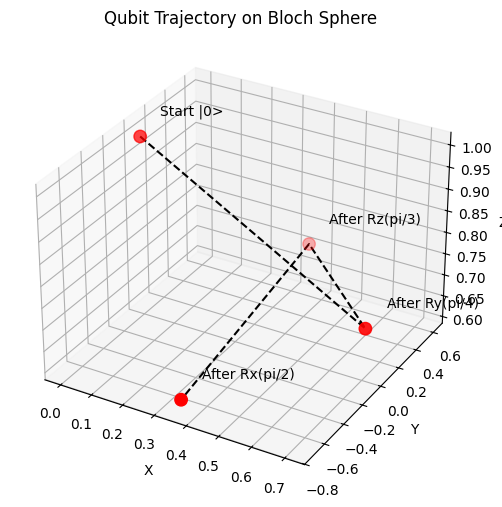

In [16]:


# Step 0: |0>
qc0 = QuantumCircuit(1)
s0 = Statevector(qc0)
x0 = 2 * np.real(np.conj(s0.data[0]) * s0.data[1])
y0 = 2 * np.imag(np.conj(s0.data[0]) * s0.data[1])
z0 = abs(s0.data[0])**2 - abs(s0.data[1])**2

# Step 1: after Ry(pi/4)
qc1 = QuantumCircuit(1)
qc1.ry(np.pi/4, 0)
s1 = Statevector(qc1)
x1 = 2 * np.real(np.conj(s1.data[0]) * s1.data[1])
y1 = 2 * np.imag(np.conj(s1.data[0]) * s1.data[1])
z1 = abs(s1.data[0])**2 - abs(s1.data[1])**2

# Step 2: after Ry(pi/4) then Rz(pi/3)
qc2 = QuantumCircuit(1)
qc2.ry(np.pi/4, 0)
qc2.rz(np.pi/3, 0)
s2 = Statevector(qc2)
x2 = 2 * np.real(np.conj(s2.data[0]) * s2.data[1])
y2 = 2 * np.imag(np.conj(s2.data[0]) * s2.data[1])
z2 = abs(s2.data[0])**2 - abs(s2.data[1])**2

# Step 3: after Ry(pi/4), Rz(pi/3), Rx(pi/2)
qc3 = QuantumCircuit(1)
qc3.ry(np.pi/4, 0)
qc3.rz(np.pi/3, 0)
qc3.rx(np.pi/2, 0)
s3 = Statevector(qc3)
x3 = 2 * np.real(np.conj(s3.data[0]) * s3.data[1])
y3 = 2 * np.imag(np.conj(s3.data[0]) * s3.data[1])
z3 = abs(s3.data[0])**2 - abs(s3.data[1])**2

# Print coordinates (part a)
print('Bloch coordinates at each step:')
print(f'  Start |0>:      x={x0:.4f}, y={y0:.4f}, z={z0:.4f}')
print(f'  After Ry(pi/4): x={x1:.4f}, y={y1:.4f}, z={z1:.4f}')
print(f'  After Rz(pi/3): x={x2:.4f}, y={y2:.4f}, z={z2:.4f}')
print(f'  After Rx(pi/2): x={x3:.4f}, y={y3:.4f}, z={z3:.4f}')

# Part (b) - plot all 4 points with connecting lines
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter([x0, x1, x2, x3], [y0, y1, y2, y3], [z0, z1, z2, z3], s=80, color='r')
ax.plot([x0, x1, x2, x3], [y0, y1, y2, y3], [z0, z1, z2, z3], 'k--')

ax.text(x0+0.05, y0+0.05, z0+0.05, 'Start |0>')
ax.text(x1+0.05, y1+0.05, z1+0.05, 'After Ry(pi/4)')
ax.text(x2+0.05, y2+0.05, z2+0.05, 'After Rz(pi/3)')
ax.text(x3+0.05, y3+0.05, z3+0.05, 'After Rx(pi/2)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Qubit Trajectory on Bloch Sphere')
plt.show()

# Part (c) - Trajectory description
# The qubit starts at |0> (north pole).
# Ry(pi/4) rotates around the Y-axis toward the equator.
# Rz(pi/3) rotates around the Z-axis, changing the XY-plane phase.
# Rx(pi/2) rotates around the X-axis toward -Y.
# The qubit moves along a curved path connecting the four points.

 ---

 ## Submission

 - [ ] All code cells executed with visible output

 - [ ] File saved as .ipynb



 **Submit to:** Canvas